In [3]:
import pandas as pd
import numpy as np
import re
import os

# 1. 사용자 지정 종목 리스트 (이름 매핑 강화)
raw_data = {
    '반도체': '삼성전자, SK하이닉스, 한미반도체, 리노공업, 원익IPS, 이오테크닉스, DB하이텍, ISC, HPSP, 주성엔지니어링, 파두, 유진테크, 피에스케이, 하나마이크론, 테크윙, 심텍, 고영, 태성, 티씨케이, 에스앤에스텍, 제주반도체, RFHIC, 두산테스나, 와이씨, 피에스케이홀딩스, 코미코, 필옵틱스, HD현대에너지솔루션, 하나머티리얼즈, 덕산네오룩스, 넥스틴, LX세미콘, SFA반도체, 케이씨텍, 가온칩스, 에이디테크놀로지, 동진쎄미켐, 솔브레인, 원익QnC, 삼성전기, LG이노텍, 대덕전자, 이수페타시스, 코리아써키트, 해성디에스, 에프에스티, 미코, 자화전자, 신성이엔지, 엠씨넥스, 네패스, 엘비세미콘, 테스, 유니테스트, 디아이, 에이피티씨, 제우스, 오로스테크놀로지, 큐알티, 티엘비, 기가비스, 워트, 에이직랜드, 오픈엣지테크놀로지, 퀄리타스반도체, 칩스앤미디어',
    '에너지': '한국전력, 한국가스공사, S-Oil, SK이노베이션, GS, 중앙에너비스, 흥구석유, 대성에너지, 지이에스, SH에너지화학',
    '방산': '한화에어로스페이스, 현대로템, LIG넥스원, 한국항공우주(KAI), 한화시스템, 풍산, SNT다이내믹스, 한화오션, 제노코, 코츠테크놀로지, 퍼스텍, 빅텍, 스페코, 휴니드, 한일단조, 포메탈, 미래아이앤지, 켄코아에어로스페이스, 쎄트렉아이, 아스트, 하이즈항공, 에이트원, 삼영이엔씨, 국영지앤엠, 컨텍, 루미르, 이노스페이스',
    '금융': 'KB금융, 신한지주, 하나금융지주, 우리금융지주, 기업은행, 카카오뱅크, BNK금융지주, JB금융지주, DGB금융지주(iM금융지주), 제주은행, 푸른저축은행'
}

def clean_name(n):
    if pd.isna(n): return ""
    return re.sub(r'\([^)]*\)', '', str(n)).strip()

def get_search_names(raw_str):
    names = [x.strip() for x in raw_str.split(',')]
    expanded = []
    for n in names:
        if '(' in n:
            expanded.append(n.split('(')[0].strip())
            expanded.append(re.search(r'\((.*?)\)', n).group(1).strip())
        else:
            expanded.append(n)
    return list(set(expanded))

# 2. 데이터 로드 및 3Q 데이터 추출
try:
    sector_df = pd.read_csv('투자섹터.csv')
    eve_df = pd.read_excel('EVEBITDA.xlsx', skiprows=8)
    roe_df = pd.read_excel('ROE.xlsx', skiprows=8)
    debt_df = pd.read_excel('부채비율.xlsx', skiprows=8)

    # 3Q 컬럼 추출 (ROE는 '3rd-Quarter' 컬럼 사용)
    eve_sub = eve_df[['코드', '3Q']].rename(columns={'코드': '종목코드', '3Q': 'EV_EBITDA'})
    roe_sub = roe_df[['코드', '3rd-Quarter']].rename(columns={'코드': '종목코드', '3rd-Quarter': 'ROE'})
    debt_sub = debt_df[['코드', '3Q']].rename(columns={'코드': '종목코드', '3Q': '부채비율'})

    df_base = sector_df[['종목코드', '종목명', '섹터명']].copy()
    df_base = df_base.merge(eve_sub, on='종목코드', how='left')
    df_base = df_base.merge(roe_sub, on='종목코드', how='left')
    df_base = df_base.merge(debt_sub, on='종목코드', how='left')

    for col in ['EV_EBITDA', 'ROE', '부채비율']:
        df_base[col] = pd.to_numeric(df_base[col], errors='coerce')

    # 3. 매칭 및 카테고리 분류
    final_list = []
    for cat, raw_str in raw_data.items():
        target_names = get_search_names(raw_str)
        subset = df_base[df_base['종목명'].apply(clean_name).isin(target_names)].copy()
        subset['투자카테고리'] = cat
        final_list.append(subset)

    df_res = pd.concat(final_list).drop_duplicates(subset=['종목코드'])

    # 4. ⭐ 필터링: 오직 3Q 데이터 기반 양수(+) 종목만
    df_ranked = df_res[(df_res['EV_EBITDA'] > 0) & (df_res['ROE'] > 0) & (df_res['부채비율'] > 0)].copy()

    # 5. 순위 계산 (카테고리별)
    df_ranked['rank_EV'] = df_ranked.groupby('투자카테고리')['EV_EBITDA'].rank(ascending=True)
    df_ranked['rank_ROE'] = df_ranked.groupby('투자카테고리')['ROE'].rank(ascending=False)
    df_ranked['rank_Debt'] = df_ranked.groupby('투자카테고리')['부채비율'].rank(ascending=True)

    df_ranked['종합점수'] = df_ranked[['rank_EV', 'rank_ROE', 'rank_Debt']].mean(axis=1)
    df_ranked['순위'] = df_ranked.groupby('투자카테고리')['종합점수'].rank(method='min')

    # 6. 결과 출력
    pd.set_option('display.max_rows', None)
    sorted_res = df_ranked.sort_values(['투자카테고리', '순위'])
    
    print("="*90)
    print("📊 [3Q 데이터 기준] 카테고리별 최종 순위 (양수 종목 전체)")
    print("="*90)

    for cat in raw_data.keys():
        print(f"\n[{cat}] 섹터 순위")
        subset = sorted_res[sorted_res['투자카테고리'] == cat][['순위', '종목명', 'EV_EBITDA', 'ROE', '부채비율']]
        if subset.empty:
            print("조건(3Q 양수 지표)을 만족하는 종목이 없습니다.")
        else:
            print(subset.to_string(index=False))
        print("-" * 90)

    sorted_res.to_csv('스크리닝_3Q_최종순위.csv', index=False, encoding='utf-8-sig')
    print("\n✅ 결과가 '스크리닝_3Q_최종순위.csv'로 저장되었습니다.")

except Exception as e:
    print(f"오류 발생: {e}")

📊 [3Q 데이터 기준] 카테고리별 최종 순위 (양수 종목 전체)

[반도체] 섹터 순위
  순위        종목명  EV_EBITDA   ROE   부채비율
 1.0   피에스케이홀딩스      19.11 26.23  16.51
 2.0     SK하이닉스      16.84 43.20  48.43
 3.0      피에스케이      30.07 15.38  17.60
 4.0      DB하이텍      15.09 12.38  31.37
 5.0       리노공업      67.73 23.61  10.57
 6.0       삼성전자      19.14  8.37  26.64
 6.0      한미반도체     127.49 40.01  19.41
 6.0       티씨케이      69.18 14.20   8.04
 9.0 HD현대에너지솔루션      20.91  8.06  25.50
10.0        네패스      15.46 19.55 186.42
10.0         테스      71.50 19.70  23.03
12.0       엠씨넥스      26.68 19.34  58.91
12.0       HPSP     160.23 31.53  19.67
14.0      제주반도체      42.16 18.57  45.02
15.0         미코      26.58 29.33 209.49
16.0        ISC      67.55  9.01  15.26
17.0       유진테크     150.94 15.48  15.41
18.0      LX세미콘      20.84  7.82  32.36
19.0     이오테크닉스      93.40  9.08  12.39
20.0     에스앤에스텍      63.10 15.89  43.33
20.0        코미코      33.49 23.68 169.98
22.0     칩스앤미디어     144.19 11.74  15.41
23.0       솔브레인      42.02  6.

C:\Users\kjg12\AppData\Local\Temp\ipykernel_10288\2613523637.py:104: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\kjg12\AppData\Local\Temp\ipykernel_10288\2613523637.py:104: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\kjg12\AppData\Local\Temp\ipykernel_10288\2613523637.py:104: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\kjg12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kjg12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kjg12\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HI

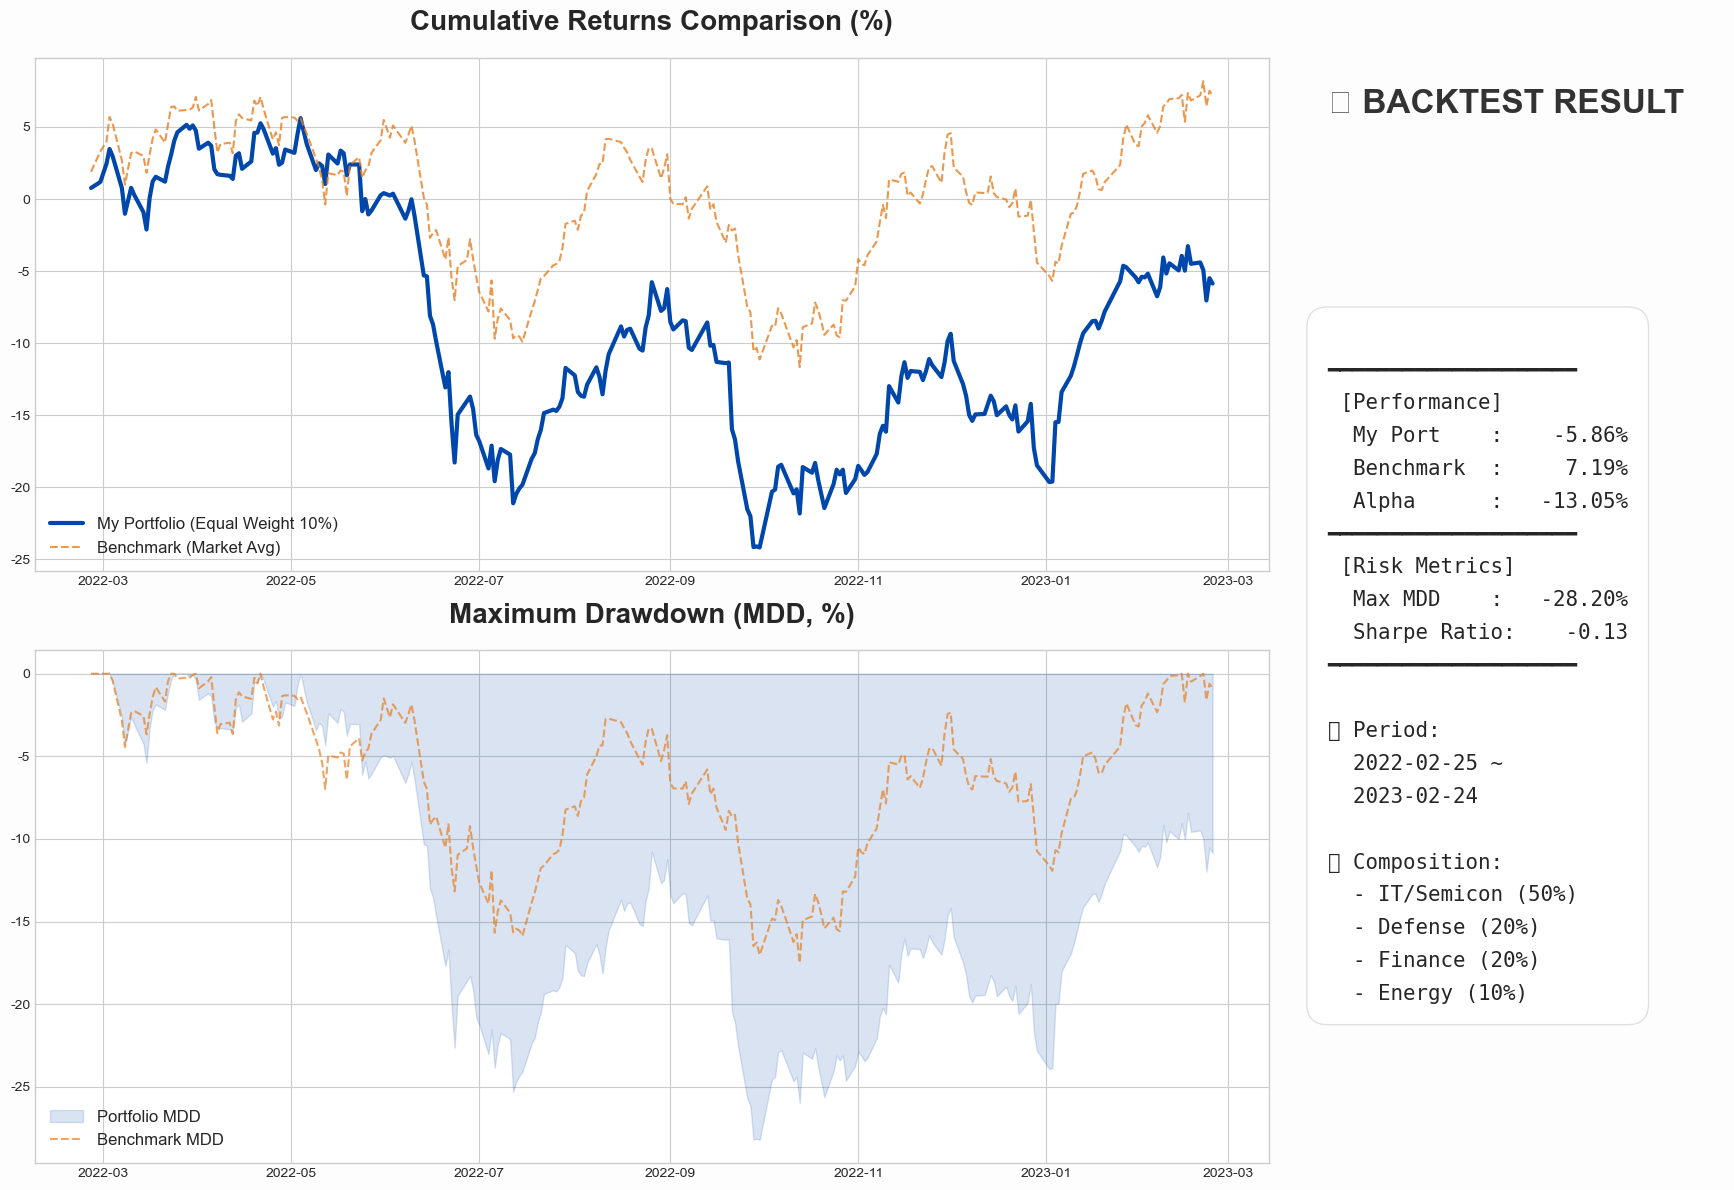

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re

# 1. Style Setting
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Basic Font Setting
plt.rcParams['axes.unicode_minus'] = False 

# 3. Data Load & Calculation
try:
    price_df = pd.read_excel('주식가격.xlsx', skiprows=8)

    portfolio_info = {
        'JB Financial': 'A175330', 'Shinhan Financial': 'A055550', 'PSK Holdings': 'A031980',
        'SK Hynix': 'A000660', 'PSK': 'A319660', 'DB HiTek': 'A000990',
        'Leeno Industrial': 'A058470', 'Hanwha Aero': 'A012450', 'SNT Dynamics': 'A003570', 'GS': 'A078930'
    }
    
    portfolio_codes = list(portfolio_info.values())
    date_cols = [c for c in price_df.columns if re.match(r'\d{4}-\d{2}-\d{2}', str(c))]

    top_50 = price_df['코드'].unique()[:50]
    df_filtered = price_df[price_df['코드'].isin(portfolio_codes + list(top_50))]
    pivot_prices = df_filtered.melt(id_vars='코드', value_vars=date_cols).pivot(index='variable', columns='코드', values='value').ffill().dropna()
    pivot_prices.index = pd.to_datetime(pivot_prices.index)

    # --- 기간 수정 부분: 러우전쟁 발발(2022-02-24) 후 1년 ---
    start_date = '2022-02-24'
    end_date = '2023-02-24'
    pivot_prices = pivot_prices.loc[start_date:end_date]
    # ---------------------------------------------------

    returns = pivot_prices.pct_change().dropna()
    port_daily_rets = returns[portfolio_codes].mean(axis=1) 
    bench_daily_rets = returns[top_50].mean(axis=1)

    port_cum = (1 + port_daily_rets).cumprod() - 1
    bench_cum = (1 + bench_daily_rets).cumprod() - 1

    def get_mdd(cum_rets):
        wealth = 1 + cum_rets
        return (wealth - wealth.cummax()) / wealth.cummax()

    port_mdd, bench_mdd = get_mdd(port_cum), get_mdd(bench_cum)

    # 4. Visualization
    fig = plt.figure(figsize=(18, 12), facecolor='#FDFDFD')
    gs = gridspec.GridSpec(2, 2, width_ratios=[2.8, 1], height_ratios=[1, 1])

    # [Top Left] Cumulative Returns
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(port_cum.index, port_cum * 100, label='My Portfolio (Equal Weight 10%)', color='#0047AB', linewidth=3)
    ax1.plot(bench_cum.index, bench_cum * 100, label='Benchmark (Market Avg)', color='#E67E22', linestyle='--', alpha=0.8)
    ax1.set_title('Cumulative Returns Comparison (%)', fontsize=20, fontweight='bold', pad=20)
    ax1.legend(fontsize=12)

    # [Bottom Left] Drawdown
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.fill_between(port_mdd.index, port_mdd * 100, 0, color='#0047AB', alpha=0.15, label='Portfolio MDD')
    ax2.plot(bench_mdd.index, bench_mdd * 100, label='Benchmark MDD', color='#E67E22', linestyle='--', alpha=0.7)
    ax2.set_title('Maximum Drawdown (MDD, %)', fontsize=20, fontweight='bold', pad=20)
    ax2.legend(fontsize=12)

    # [Right] Statistics Table
    ax_stat = fig.add_subplot(gs[:, 1])
    ax_stat.axis('off')

    p_ret, b_ret = port_cum.iloc[-1] * 100, bench_cum.iloc[-1] * 100
    p_mdd_val = port_mdd.min() * 100
    alpha = p_ret - b_ret
    sharpe = (port_daily_rets.mean() * 252) / (port_daily_rets.std() * np.sqrt(252))

    stats_title = "📊 BACKTEST RESULT"
    stats_content = (
        f"\n{'━'*20}\n"
        f" [Performance]\n"
        f"  My Port    : {p_ret:>8.2f}%\n"
        f"  Benchmark  : {b_ret:>8.2f}%\n"
        f"  Alpha      : {alpha:>8.2f}%\n"
        f"{'━'*20}\n"
        f" [Risk Metrics]\n"
        f"  Max MDD    : {p_mdd_val:>8.2f}%\n"
        f"  Sharpe Ratio: {sharpe:>8.2f}\n"
        f"{'━'*20}\n\n"
        f"📅 Period:\n"
        f"  {port_cum.index[0].date()} ~\n  {port_cum.index[-1].date()}\n\n"
        f"🎯 Composition:\n"
        f"  - IT/Semicon (50%)\n"
        f"  - Defense (20%)\n"
        f"  - Finance (20%)\n"
        f"  - Energy (10%)"
    )

    ax_stat.text(0.1, 0.95, stats_title, fontsize=24, fontweight='bold', color='#333333')
    ax_stat.text(0.1, 0.45, stats_content, fontsize=15, 
                  verticalalignment='center', linespacing=1.8,
                  family='monospace',
                  bbox=dict(boxstyle='round,pad=1', facecolor='white', edgecolor='#E0E0E0', alpha=1))

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error Occurred: {e}")